In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/25-1/ICV/project

Mounted at /content/drive
/content/drive/MyDrive/25-1/ICV/project


In [ ]:
!apt-get update
!apt-get install -y tesseract-ocr
!apt-get install -y tesseract-ocr-kor
!pip install pytesseract pillow

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

In [ ]:
import cv2
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import os

# sample_photos 폴더 내 모든 이미지 파일 경로 리스트로 가져오기
photo_folder = './Sample_Photos'
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
sorted_filenames = sorted(os.listdir(photo_folder))
photo_list = [
    os.path.join(photo_folder, fname)
    for fname in sorted_filenames
    if fname.lower().endswith(image_extensions)
]

print(f"총 {len(photo_list)}개의 이미지 파일을 찾았습니다.")

총 9개의 이미지 파일을 찾았습니다.


## detection

In [ ]:
import pytesseract
from pytesseract import Output
import numpy as np

# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
pytesseract.pytesseract.tesseract_cmd = '/usr/bin/tesseract'


def ocr_highlighted_images(highlighted_image_results):
    conf_thresholds = [0, 10, 50]
    psm_modes = {
        "psm6": '--oem 3 --psm 6 -l kor+eng',
        "psm8": '--oem 3 --psm 8 -l kor+eng',
        "psm10": '--oem 3 --psm 10 -l kor+eng'
    }
    all_detected_boxes = []  # 모든 box 정보 저장

    for result in highlighted_image_results:
        highlighted_image = result["highlighted_image"]
        tolerance = result["tolerance"]

        gray = cv2.cvtColor(highlighted_image, cv2.COLOR_RGB2GRAY)
        blurred = cv2.GaussianBlur(gray, (3, 3), 0.01)
        _, binary = cv2.threshold(blurred, 10, 255, cv2.THRESH_BINARY)
        dilated = cv2.dilate(binary, np.ones((2, 2), np.uint8), iterations=1)

        image_height, image_width = dilated.shape

        for conf_threshold in conf_thresholds:
            for label, config in psm_modes.items():
                results = pytesseract.image_to_data(dilated, output_type=Output.DICT, config=config)
                n_boxes = len(results['level'])
                for i in range(n_boxes):
                    text = results['text'][i].strip()
                    conf = int(results['conf'][i])
                    x = results['left'][i]
                    y = results['top'][i]
                    w = results['width'][i]
                    h = results['height'][i]

                    if (conf > conf_threshold and text != '' and
                        x > 0 and y > 0 and x + w < image_width and y + h < image_height):

                        # box 정보 저장
                        all_detected_boxes.append({
                            "tolerance": tolerance,
                            "psm": label,
                            "conf_threshold": conf_threshold,
                            "x": x,
                            "y": y,
                            "w": w,
                            "h": h,
                            "conf": conf,
                            "text": text
                        })
    return all_detected_boxes

# box 크기 조정 및 줄이기
def color_similar(pixel, target_color, tolerance=30):
    return np.all(np.abs(pixel.astype(int) - target_color.astype(int)) <= tolerance)

In [ ]:
# 필요 함수 임포트: ocr_highlighted_images, color_similar
# from your_module import ocr_highlighted_images, color_similar

def extract_target_color(image, crop, target_pixel):
    """
    한 장의 이미지에서 지정된 crop 영역을 잘라내고,
    해당 크롭된 영역 내 지정 픽셀의 RGB 색상(target_color)을 반환합니다.

    Args:
        image (np.ndarray): 원본 이미지 (RGB)
        crop (dict): {'top','bottom','left','right'} 크롭 좌표
        target_pixel (tuple): (y, x) 크롭된 이미지 내 기준 픽셀 좌표

    Returns:
        np.ndarray: target_color (shape=(3,), dtype=int)
    """
    top, bottom = crop['top'], crop['bottom']
    left, right = crop['left'], crop['right']
    cropped = image[top:bottom, left:right]
    y, x = target_pixel
    target_color = cropped[y, x].astype(int)
    return target_color


def make_subtitle_mask_and_box(image, crop, target_color, tolerance):
    """
    한 장의 이미지에서 지정된 crop 영역 내에서
    target_color ± tolerance 범위로 mask를 만들고,
    OCR 후보 박스 및 이후 각종 필터링과 확장을 통해
    전체 이미지 좌표 기준의 mask_bbox와 bbox를 반환합니다.

    Args:
        image (np.ndarray): 원본 이미지 (RGB)
        crop (dict): {'top','bottom','left','right'} 크롭 좌표
        target_color (np.ndarray): 추출된 자막 색상
        tolerance (int): 색상 허용 오차

    Returns:
        dict: {
            'mask_bbox': np.ndarray,  # 전체 이미지 크기의 이진 마스크
            'bbox': tuple or None,    # 전체 이미지 좌표계 바운딩 박스
        }
    """
    # 1) 크롭된 이미지 영역
    top, bottom = crop['top'], crop['bottom']
    left, right = crop['left'], crop['right']
    cropped = image[top:bottom, left:right]

    # 2) 색상 기반 크롭 마스크 생성
    highlighted_images = []
    for tol in range(5, 51, 5):
        # mask/highlight 생성 코드 (tolerance=tol)
        lower = np.clip(target_color - tol, 0, 255)
        upper = np.clip(target_color + tol, 0, 255)
        mask_crop = cv2.inRange(cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR),
                          lower[::-1], upper[::-1])
        highlighted = np.zeros_like(cropped)
        highlighted[mask_crop == 255] = [255,255,255]

        highlighted_images.append({
            'tolerance': tol,
            'highlighted_image': highlighted,
        })

    # 3) OCR 후보 박스 생성
    candidates = ocr_highlighted_images(highlighted_images)

    # 4) color_similar 기반 첫 트리밍
    trimmed = []
    for box in candidates:
        x0, y0, w, h = box['x'], box['y'], box['w'], box['h']
        x_min, y_min = x0, y0
        x_max, y_max = x0 + w, y0 + h
        # 위쪽 트리밍
        for yy in range(y_min, y_max):
            if np.any([color_similar(p, target_color, tolerance=30) for p in cropped[yy, x_min:x_max]]):
                y_min = yy; break
        # 아래쪽 트리밍
        for yy in range(y_max-1, y_min-1, -1):
            if np.any([color_similar(p, target_color, tolerance=30) for p in cropped[yy, x_min:x_max]]):
                y_max = yy + 1; break
        # 왼쪽 트리밍
        for xx in range(x_min, x_max):
            if np.any([color_similar(p, target_color, tolerance=30) for p in cropped[y_min:y_max, xx]]):
                x_min = xx; break
        # 오른쪽 트리밍
        for xx in range(x_max-1, x_min-1, -1):
            if np.any([color_similar(p, target_color, tolerance=30) for p in cropped[y_min:y_max, xx]]):
                x_max = xx + 1; break
        if x_max > x_min and y_max > y_min:
            trimmed.append({'x': x_min, 'y': y_min, 'w': x_max-x_min, 'h': y_max-y_min})

    # 5) 최빈 높이 필터링
    heights = [b['h'] for b in trimmed]
    if heights:
        hist_h, bins_h = np.histogram(heights, bins=20)
        i_h = hist_h.argmax(); h_lo, h_hi = bins_h[i_h], bins_h[i_h+1]
        mode_h = [b for b in trimmed if h_lo <= b['h'] <= h_hi]
    else:
        mode_h = []

    # 6) 최빈 너비 필터링
    x_edges = []
    for b in mode_h:
        x_edges += [b['x'], b['x'] + b['w']]

    if x_edges:
        # 히스토그램 계산
        hist_x, bins_x = np.histogram(x_edges, bins=40)
        # 박스 수
        sample_count = len(x_edges) // 2
        threshold = sample_count / 10

        filtered = []
        for bin_idx, count in enumerate(hist_x):
            if count > threshold:
                bin_left  = bins_x[bin_idx]
                bin_right = bins_x[bin_idx + 1]
                for b in mode_h:
                    x0, x1 = b['x'], b['x'] + b['w']
                    if (bin_left <= x0 < bin_right) or (bin_left <= x1 < bin_right):
                        filtered.append(b)
        # 중복 제거
        mode_xy = list({id(b): b for b in filtered}.values())
    else:
        mode_xy = []

    # 7) 통합 박스 및 gradient 확장
    if not mode_xy:
        return {'mask_bbox': None, 'bbox': None}
    xs = [x for b in mode_xy for x in (b['x'], b['x'] + b['w'])]
    ys = [y for b in mode_xy for y in (b['y'], b['y'] + b['h'])]

    margin = 5
    cx_min = max(0, min(xs) - margin)
    cy_min = max(0, min(ys) - margin)
    cx_max = min(cropped.shape[1], max(xs) + margin)
    cy_max = min(cropped.shape[0], max(ys) + margin)
    #
    gray = cv2.cvtColor(cropped, cv2.COLOR_RGB2GRAY)
    sob_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, 3)
    sob_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, 3)
    grad = np.sqrt(sob_x**2 + sob_y**2)
    max_expand = 40
    gradient_threshold = 60
    et = eb = el = er = 0

    for i in range(1, max_expand):
        y_line = cy_min - i
        if y_line < 0: break
        if grad[y_line, cx_min:cx_max].mean() >= gradient_threshold:
            et = i; break
    for i in range(1, max_expand):
        y_line = cy_max + i
        if y_line >= grad.shape[0]: break
        if grad[y_line, cx_min:cx_max].mean() >= gradient_threshold:
            eb = i; break
    for i in range(1, max_expand):
        x_line = cx_min - i
        if x_line < 0: break
        if grad[cy_min:cy_max, x_line].mean() >= gradient_threshold:
            el = i; break
    for i in range(1, max_expand):
        x_line = cx_max + i
        if x_line >= grad.shape[1]: break
        if grad[cy_min:cy_max, x_line].mean() >= gradient_threshold:
            er = i; break
    cx_min = max(0, cx_min - el)
    cy_min = max(0, cy_min - et)
    cx_max = min(cropped.shape[1], cx_max + er)
    cy_max = min(cropped.shape[0], cy_max + eb)

    # 8) 전체 이미지 좌표로 변환
    x_min_all, y_min_all = cx_min + left, cy_min + top
    x_max_all, y_max_all = cx_max + left, cy_max + top
    bbox = (x_min_all, y_min_all, x_max_all, y_max_all)

    # 9) bbox 영역만 포함하는 mask_bbox 생성
    mask_bbox = np.zeros_like(image[:, :, 0], dtype=np.uint8)
    mask_bbox[y_min_all:y_max_all, x_min_all:x_max_all] = mask_crop[cy_min:cy_max, cx_min:cx_max]

    return {'mask_bbox': mask_bbox, 'bbox': bbox}

In [ ]:
crop_list = [
    {"top": 100, "bottom": 300, "left": 100, "right": 1500},
    {"top": 800, "bottom": 900, "left": 100, "right": 1600},
    {"top": 800, "bottom": 950, "left": 100, "right": 1600},
    {"top": 800, "bottom": 950, "left": 100, "right": 1600},
    {"top": 800, "bottom": 950, "left": 100, "right": 1600},
    {"top": 800, "bottom": 950, "left": 100, "right": 1600},
    {"top": 800, "bottom": 950, "left": 100, "right": 1600},
    {"top": 1000, "bottom": 1200, "left": 100, "right": 2450},
    {"top": 1000, "bottom": 1200, "left": 100, "right": 2450}
]
target_pixel_list = [
    (100, 1048),
    (54, 1000),
    (50, 1000),
    (102, 1000),
    (80, 996),
    (80, 700),
    (80, 700),
    (100, 1006),
    (99, 975)
    ]

0
1
2
3
4
5
6
7
8


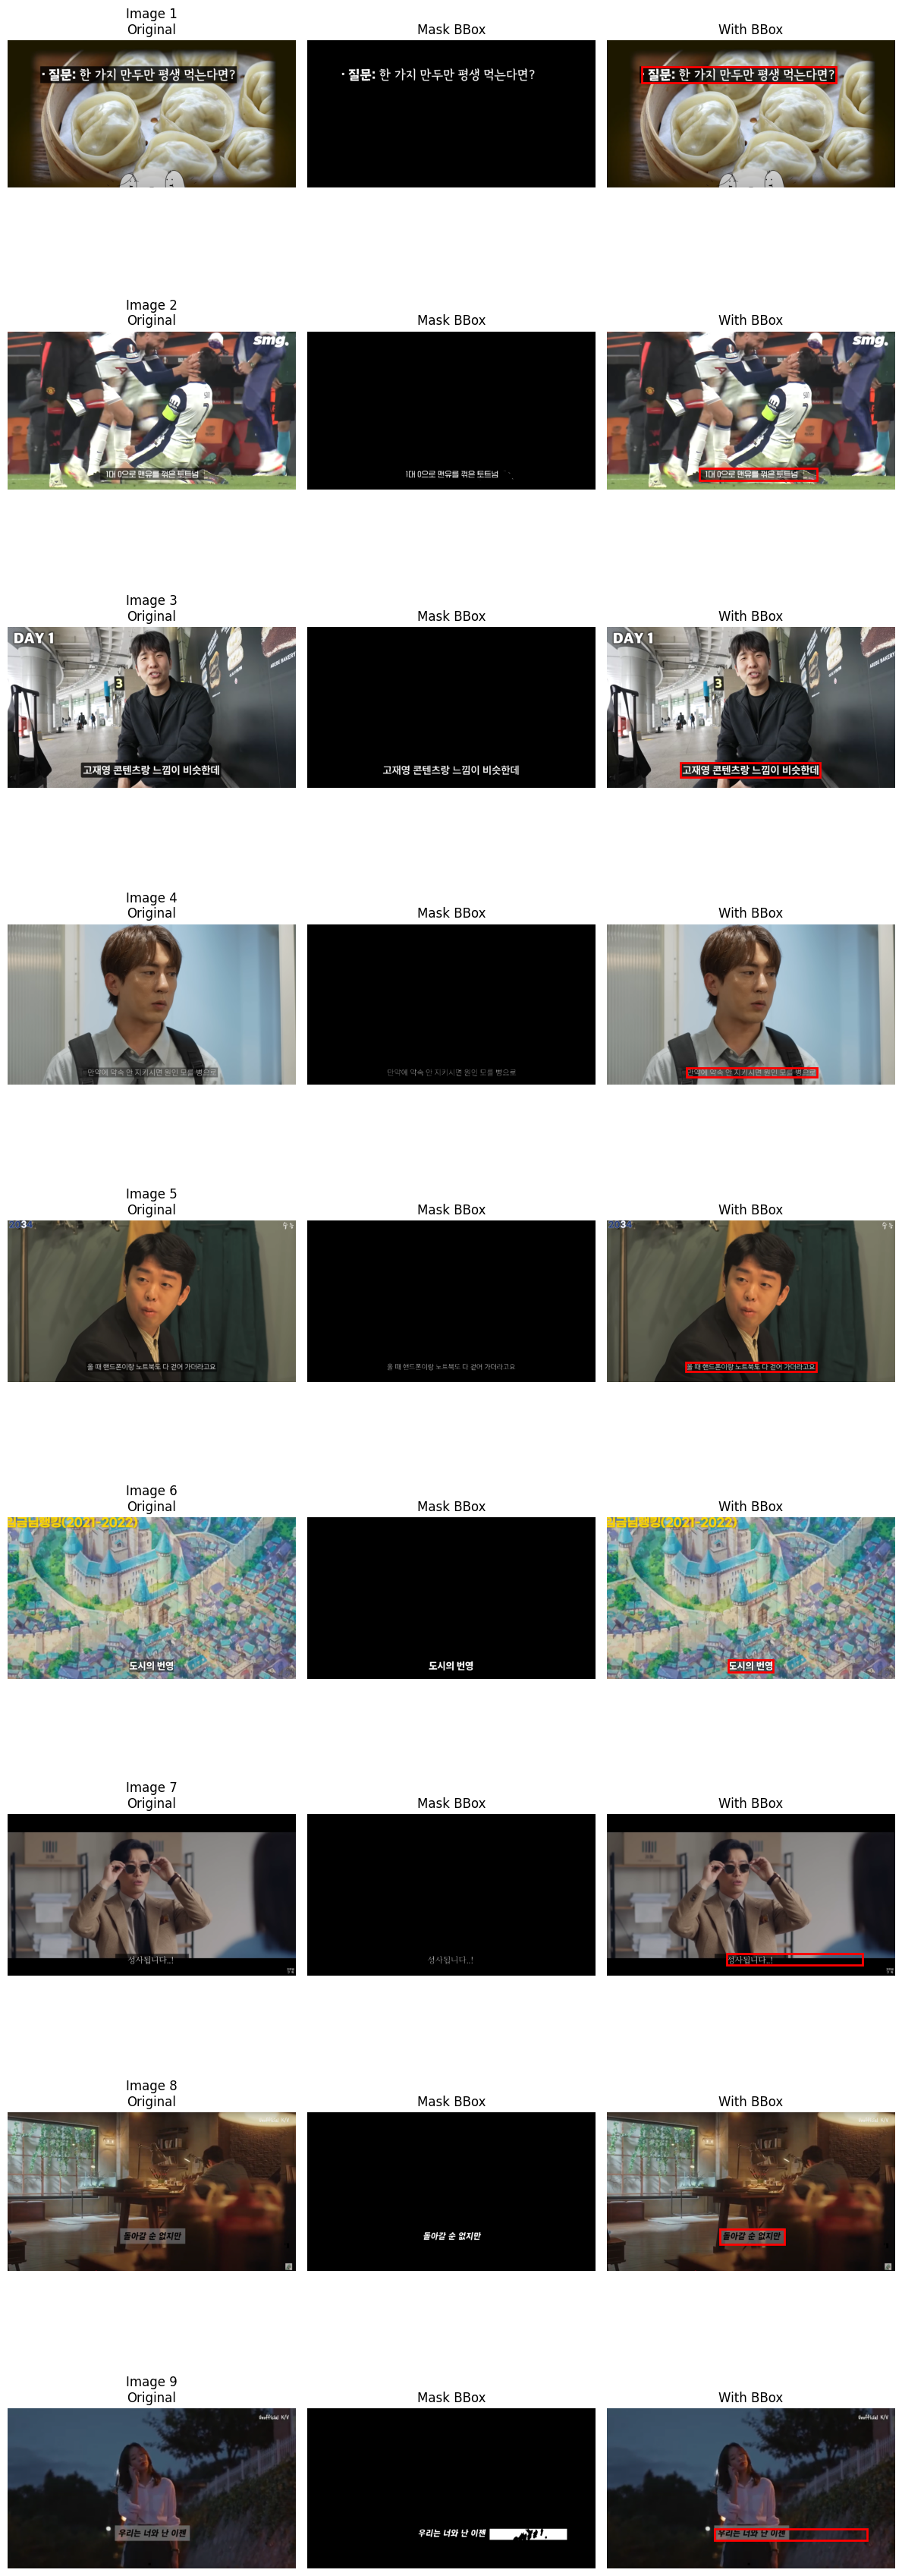

In [ ]:
# Assuming extract_target_color and make_subtitle_mask_and_box are already defined in the notebook

num_images = 9
fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))

for idx in range(num_images):
    # 1. Load and convert image
    img_path = photo_list[idx]
    img_bgr = cv2.imread(img_path)
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2. Extract target color
    crop = crop_list[idx]
    target_pixel = target_pixel_list[idx]
    target_color = extract_target_color(img, crop, target_pixel)

    # 3. Compute mask_bbox and bbox
    tolerance = 50
    result = make_subtitle_mask_and_box(img, crop, target_color, tolerance)
    mask_bbox = result['mask_bbox']
    bbox = result['bbox']

    # 4. Visualization per row
    ax_orig = axes[idx, 0]
    ax_mask = axes[idx, 1]
    ax_boxed = axes[idx, 2]

    # Original
    ax_orig.imshow(img)
    ax_orig.set_title(f'Image {idx+1}\nOriginal')
    ax_orig.axis('off')

    # Mask
    ax_mask.imshow(mask_bbox, cmap='gray')
    ax_mask.set_title('Mask BBox')
    ax_mask.axis('off')

    # Box overlay
    ax_boxed.imshow(img)
    if bbox is not None:
        x1, y1, x2, y2 = bbox
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                             edgecolor='red', facecolor='none', linewidth=2)
        ax_boxed.add_patch(rect)
    ax_boxed.set_title('With BBox')
    ax_boxed.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import cv2
import numpy as np

# 미리 정의된 함수들:
# - extract_target_color(img, crop, target_pixel)
# - make_subtitle_mask_and_box(img, crop, target_color, tolerance)

num_images = 9

# 결과를 저장할 빈 리스트들 선언
subtitle_mask_list = []   # 각 이미지의 mask_bbox (자막 배경+글자 영역)
bbox_list          = []   # 각 이미지의 bbox 좌표 (x_min, y_min, x_max, y_max) 또는 None

for idx in range(num_images):
    # 1) 이미지 로드 및 RGB 변환
    img_path = photo_list[idx]
    img_bgr  = cv2.imread(img_path)
    img      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2) 크롭 영역에서 기준 색 뽑기
    crop         = crop_list[idx]
    target_pixel = target_pixel_list[idx]
    target_color = extract_target_color(img, crop, target_pixel)

    # 3) make_subtitle_mask_and_box 로 자막 마스크와 bbox 계산
    tolerance       = 50
    result          = make_subtitle_mask_and_box(img, crop, target_color, tolerance)
    subtitle_mask   = result['mask_bbox']  # 자막(배경+글자) 이진 마스크
    bbox            = result['bbox']       # (x_min, y_min, x_max, y_max) 또는 None

    # 4) 리스트에 저장
    subtitle_mask_list.append(subtitle_mask)
    bbox_list.append(bbox)

    print(f"[{idx+1}/{num_images}] subtitle_mask 저장, bbox = {bbox}")

# 이제 subtitle_mask_list[i], bbox_list[i] 로 9개 이미지의 결과를 꺼내 쓸 수 있습니다.

[1/9] subtitle_mask 저장, bbox = (208, 157, 1377, 256)
[2/9] subtitle_mask 저장, bbox = (558, 824, 1262, 895)
[3/9] subtitle_mask 저장, bbox = (442, 814, 1284, 904)
[4/9] subtitle_mask 저장, bbox = (480, 861, 1263, 918)
[5/9] subtitle_mask 저장, bbox = (477, 853, 1263, 910)
[6/9] subtitle_mask 저장, bbox = (727, 854, 999, 929)
[7/9] subtitle_mask 저장, bbox = (716, 837, 1531, 903)
[8/9] subtitle_mask 저장, bbox = (1000, 1034, 1576, 1169)
[9/9] subtitle_mask 저장, bbox = (954, 1067, 2306, 1165)


In [ ]:
import pickle

# ─────────────────────────────────────────
# 위에서 subtitle_mask_list, bbox_list를 채운 후
# ─────────────────────────────────────────

# 파일명 지정
save_path = 'subtitle_data.pkl'  # 원하는 경로를 지정

# subtitle_mask_list와 bbox_list를 하나의 튜플로 묶어서 저장
with open(save_path, 'wb') as f:
    pickle.dump((subtitle_mask_list, bbox_list), f)

print(f"▶️ subtitle_mask_list, bbox_list가 '{save_path}'에 저장되었습니다.")


▶️ subtitle_mask_list, bbox_list가 'subtitle_data.pkl'에 저장되었습니다.


## inpainting

In [ ]:
import numpy as np

def make_bbox_mask(image, bbox):
    """
    전체 이미지 크기의 Boolean 마스크를 생성합니다.
    bbox 내부는 True, 나머지는 False.

    Args:
        image (np.ndarray): 전체 이미지 (HxWxC, uint8, 0~255)
        bbox (tuple): (x_min, y_min, x_max, y_max)  # 전체 이미지 좌표계 사각형

    Returns:
        np.ndarray (dtype=bool): shape (H, W)
    """
    H, W = image.shape[:2]
    x_min, y_min, x_max, y_max = bbox

    # 1) 전체 이미지 크기의 False로 초기화된 Boolean 마스크
    mask = np.zeros((H, W), dtype=bool)

    # 2) bbox 범위만 True로 설정 (y축=행, x축=열 순서)
    mask[y_min:y_max, x_min:x_max] = True

    return mask


def get_border_coord_pairs_from_masks(bbox_mask, subtitle_mask):
    """
    bbox_mask(사각형) 및 mask(자막 영역) 두 마스크를 받아,
    “사각형 내부 자막 영역의 경계 픽셀”과 “경계 바로 바깥 픽셀” 좌표 쌍을 계산합니다.

    Args:
        bbox_mask (np.ndarray of bool): 전체 이미지 크기의 마스크.
                                        True인 영역이 사각형(자막 배경) 영역.
        subtitle_mask (np.ndarray of bool): 전체 이미지 크기의 마스크.
                                        True인 영역이 자막(글자+배경) 영역.

    Returns:
        Co_coords (list of (y,x)): 사각형 내부 자막 영역의 경계 픽셀 좌표
        Cu_coords (list of (y,x)): 해당 경계 픽셀에 인접한 “사각형 안이지만 자막 밖” 픽셀 좌표
    """
    H, W = bbox_mask.shape

    Co_coords = [] # inside-box border coordinates
    Cu_coords = [] # corresponding outside-box coordinates

    # 4‐neighborhood vectors (상, 하, 좌, 우)
    neighbors = [(10, 0), (-10, 0), (0, 10), (0, -10)]

    #   자막 배경 마스크: 사각형 안이면서( bbox_mask ) 글자 영역이 아닌( ~mask_bbox )
    bg_mask = bbox_mask & (~subtitle_mask)

    # 경계 픽셀: inside_mask 픽셀 중에서,
    # 어떤 인접 픽셀이 outside_mask인 픽셀
    ys, xs = np.where(bg_mask)

    for (y, x) in zip(ys, xs):
        for dy, dx in neighbors:
            ny, nx = y + dy, x + dx
            # 이미지 범위 안이고, 배경 마스크가 아닌 픽셀인 경우
            if 0 <= ny < H and 0 <= nx < W and not bg_mask[ny, nx]:
              Co_coords.append((y, x))
              Cu_coords.append((ny, nx))
              break

    return Co_coords, Cu_coords


def estimate_box_color_and_opacity(image, bbox_mask, subtitle_mask,
                                   max_iter=100, tol=1e-6):
    """
    이미지와 bbox_mask, subtitle_mask를 받아 자막 배경색 C_b와 전역 불투명도 alpha를 추정합니다.

    Args:
        image (np.ndarray): 원본 이미지 (HxWx3, uint8, 0~255)
        bbox_mask (np.ndarray of bool): 전체 이미지 크기의 마스크.
                                        True인 픽셀이 자막이 포함될 사각형 영역.
        subtitle_mask (np.ndarray of bool): 전체 이미지 크기의 마스크.
                                        True인 픽셀이 실제 자막(배경+글자) 영역.
        max_iter (int): EM 반복 최대 횟수 (기본값=10)
        tol (float): 수렴 허용 오차 (기본값=1e-6)

    Returns:
        C_b (np.ndarray shape=(3,)): 추정된 박스 배경색 (RGB, float [0,1])
        alpha (float): 추정된 전역 불투명도 (0~1)
    """
    H, W = bbox_mask.shape

    # 1) "자막 배경" 마스크: bbox_mask 안쪽에서 글자(subtitle_mask)만 제외
    bg_mask = bbox_mask & (~subtitle_mask)  # Boolean mask (HxW)

    # 2) 픽셀 값을 [0,1] float로 변환
    img_f = image.astype(np.float32) / 255.0

    # # 3) 초기 C_b: bg_mask가 True인 픽셀의 평균색
    # if np.any(bg_mask):
    #     Cb = np.mean(img_f[bg_mask], axis=0)  # shape (3,)
    # else:
    #     # 배경 픽셀이 아예 없을 경우, 전체 자막 영역 평균으로 초기화
    #     Cb = np.mean(img_f[subtitle_mask], axis=0)

    # 3) 메모리 절약형 Cb 계산
    #    (마스크된 픽셀을 한 번에 뽑지 않고, 채널별로 곱해서 합+개수로 처리)
    if np.any(bg_mask):
        # 채널별 합
        sum_r = np.sum(img_f[..., 0] * bg_mask)
        sum_g = np.sum(img_f[..., 1] * bg_mask)
        sum_b = np.sum(img_f[..., 2] * bg_mask)
        # 픽셀 개수
        count = np.count_nonzero(bg_mask)
        # 평균 (Cb)
        Cb = np.array([sum_r / count, sum_g / count, sum_b / count], dtype=np.float32)
    else:
        # bg_mask가 모두 False인 경우: subtitle_mask 영역 전체의 평균
        sum_r = np.sum(img_f[..., 0] * bbox_mask)
        sum_g = np.sum(img_f[..., 1] * bbox_mask)
        sum_b = np.sum(img_f[..., 2] * bbox_mask)
        count = np.count_nonzero(subtitle_mask)
        Cb = np.array([sum_r / count, sum_g / count, sum_b / count], dtype=np.float32)

    # 4) 초기 alpha
    alpha = 0.5

    # 5) 경계 픽셀 좌표 쌍 생성
    Co_coords, Cu_coords = get_border_coord_pairs_from_masks(bbox_mask, subtitle_mask)
    # Co_coords, Cu_coords 는 리스트 of (y, x)

    # 6) EM 스타일 반복 추정
    for i in range(max_iter):
        # (a) E-step: alpha 추정 (least squares 식 사용)
        numer = 0.0
        denom = 0.0
        for (yo, xo), (yu, xu) in zip(Co_coords, Cu_coords):
            Co = img_f[yo, xo]  # shape (3,)
            Cu = img_f[yu, xu]  # shape (3,)
            diff_bu = Cb - Cu    # shape (3,)
            diff_ou = Co - Cu    # shape (3,)
            numer += float(np.dot(diff_ou, diff_bu))
            denom += float(np.dot(diff_bu, diff_bu))
        # 분모가 0이 되지 않도록 안전하게 처리
        alpha_new = np.clip(numer / (denom + 1e-12), 0.0, 1.0)

        # (b) M-step: C_b 추정 (Inverse blending 식, 메디안 사용)
        cb_parts = []
        for (yo, xo), (yu, xu) in zip(Co_coords, Cu_coords):
            Co = img_f[yo, xo]
            Cu = img_f[yu, xu]
            # 역블렌딩: Cb_i = (Co - (1 - alpha_new)*Cu) / alpha_new
            # alpha_new이 0에 가까우면 불안정하므로 1e-12 더함
            part = (Co - (1.0 - alpha_new) * Cu) / (alpha_new + 1e-12)
            cb_parts.append(part)
        cb_stack = np.stack(cb_parts, axis=0)  # shape (N, 3)
        Cb_new = np.median(cb_stack, axis=0)   # shape (3,)

        # (c) 수렴 체크
        if np.linalg.norm(Cb_new - Cb) < tol and abs(alpha_new - alpha) < tol:
            Cb, alpha = Cb_new, alpha_new
            break

        # (d) 파라미터 업데이트
        Cb, alpha = Cb_new, alpha_new

    return Cb, alpha


def apply_inverse_alpha_to_bbox(img_rgb, bbox_mask, Cb, alpha):
    """
    이미지와 bbox_mask, subtitle_mask, Cb, alpha를 입력받아,
    bbox_mask 영역(자막 배경+글자 영역) 내에서 subtitle_mask(자막 글자/배경 영역)에 한해
    inverse alpha blending을 적용한 새로운 이미지를 반환합니다.

    Args:
        img_rgb (np.ndarray): 원본 이미지 (HxWx3, uint8, 0~255)
        bbox_mask (np.ndarray of bool): 전체 이미지 크기의 Boolean 마스크.
                                        True인 픽셀이 자막이 포함될 사각형(배경+글자) 영역.
        Cb (np.ndarray of float, shape=(3,)): 자막 박스 배경색 (정규화된 [0,1] RGB)
        alpha (float): 자막 박스 전역 불투명도 (0~1)

    Returns:
        result_img (np.ndarray): 원본 이미지와 동일한 크기의 uint8 이미지.
                                 bbox_mask영역 내에서 subtitle_mask가 True인 픽셀들에
                                 inverse alpha blending이 적용되어 있습니다.
    """
    # 1) 입력 이미지 float화: [0,1] 범위로 변환
    img_f = img_rgb.astype(np.float32) / 255.0

    # 2) 결과 이미지 초기화 (float [0,1])
    result = img_f.copy()

    # 3) inverse alpha blending:
    #    Co = result[y,x], Cu = (Co - alpha * Cb) / (1 - alpha)
    #    ※ alpha=1인 경우 분모가 0이므로, 그런 경우엔 그냥 Cb나 흰색(1,1,1)으로 대체할 수 있지만
    #       통상 alpha<1로 추정되므로 여기선 간단히 처리합니다.
    if alpha >= 1.0 - 1e-6:
        # alpha가 1에 가까우면 무효화된 폼 방지: mask 영역을 전부 Cb로 채움
        for c in range(3):
            channel = result[..., c]
            channel[bbox_mask] = Cb[c]
            result[..., c] = channel
    else:
        # 정상적인 inverse 계산
        # (Co - alpha*Cb) / (1 - alpha) 를 픽셀별로 적용
        Co_vals = img_f[bbox_mask]                # shape (N, 3)
        Cu_vals = (Co_vals - alpha * Cb) / (1.0 - alpha)
        # [0,1] 범위 클램프
        Cu_vals = np.clip(Cu_vals, 0.0, 1.0)
        # 결과 대입
        result[bbox_mask] = Cu_vals

    # 4) [0,1] -> [0,255] uint8로 변환
    result_img = (result * 255.0).round().astype(np.uint8)
    return result_img

#### inverse background

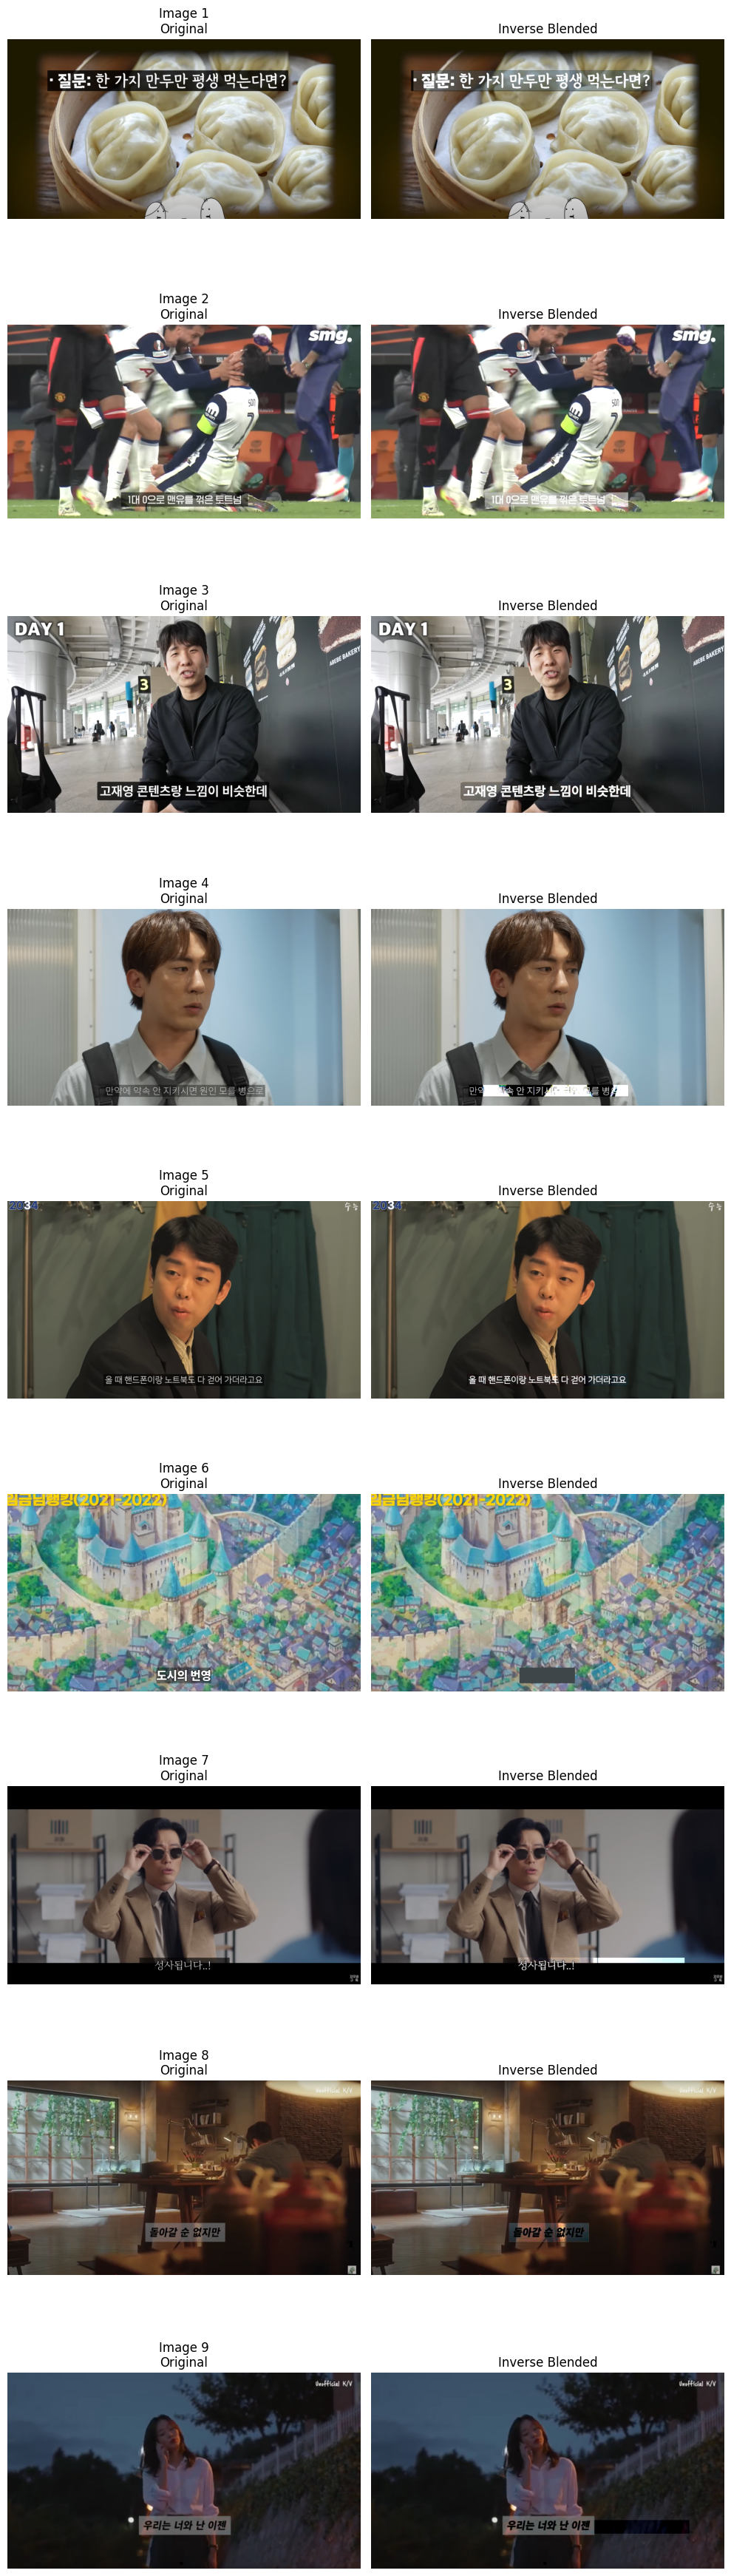

In [ ]:
import cv2
import matplotlib.pyplot as plt


import pickle
with open('subtitle_data.pkl', 'rb') as f:
    subtitle_mask_list, bbox_list = pickle.load(f)

# Assuming the following functions are already defined in the environment:
# extract_target_color, make_subtitle_mask_and_box,
# make_bbox_mask, estimate_box_color_and_opacity, apply_inverse_alpha_to_bbox

num_images = 9
fig, axes = plt.subplots(num_images, 2, figsize=(10, 4 * num_images))

for idx in range(num_images):
    # Load and convert image
    img_path = photo_list[idx]
    img_bgr = cv2.imread(img_path)
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Retrieve saved subtitle_mask and bbox
    subtitle_mask = subtitle_mask_list[idx]  # Boolean or uint8 mask
    bbox = bbox_list[idx]  # (x_min, y_min, x_max, y_max) or None

    # Create bbox_mask from bbox
    if bbox is not None:
        bbox_mask = make_bbox_mask(img, bbox)
    else:
        bbox_mask = np.zeros(img.shape[:2], dtype=bool)

    # Estimate Cb and alpha
    Cb, alpha = estimate_box_color_and_opacity(img, bbox_mask, subtitle_mask)

    # Apply inverse alpha blending
    recovered = apply_inverse_alpha_to_bbox(img, bbox_mask, Cb, alpha)

    # Visualization per row
    ax_orig = axes[idx, 0]
    ax_rec = axes[idx, 1]

    # Original image
    ax_orig.imshow(img)
    ax_orig.set_title(f'Image {idx+1}\nOriginal')
    ax_orig.axis('off')

    # Inverse-blended (recovered)
    ax_rec.imshow(recovered)
    ax_rec.set_title('Inverse Blended')
    ax_rec.axis('off')

plt.tight_layout()
plt.show()


#### inpaint subtitle

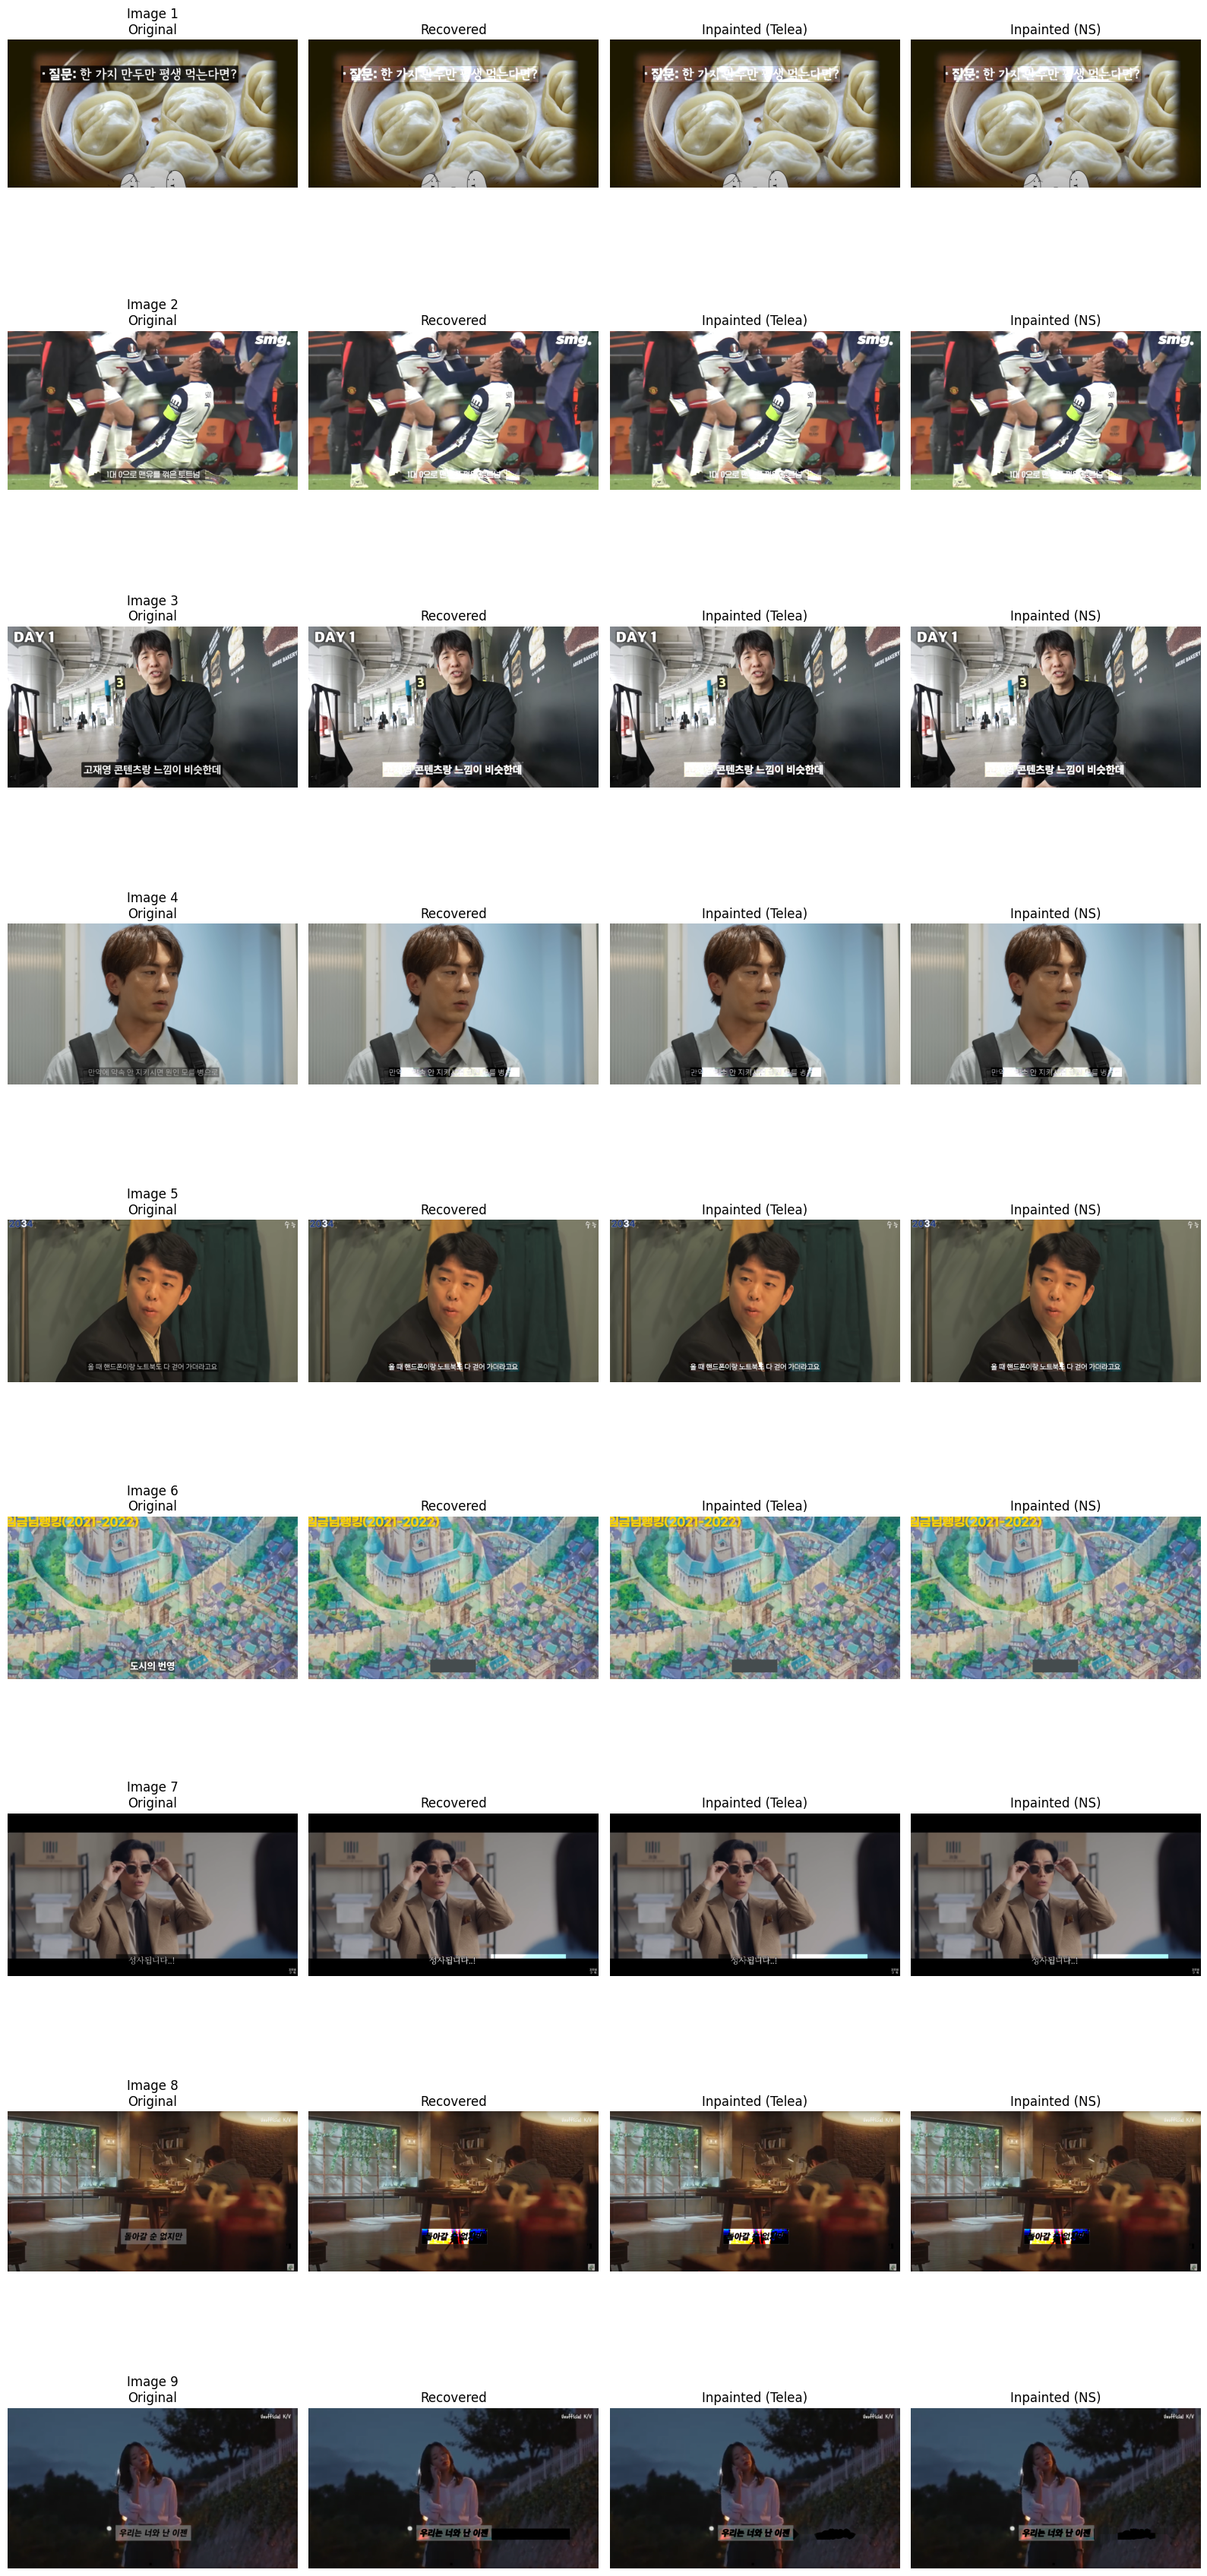

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------------
# 사전 준비:
#   photo_list          : 이미지 파일 경로 리스트
#   subtitle_mask_list  : 각 이미지를 Boolean 마스크로 만든 리스트
#   bbox_list           : 각 이미지의 (x_min, y_min, x_max, y_max) 튜플 리스트
#   make_bbox_mask, estimate_box_color_and_opacity, apply_inverse_alpha_to_bbox 함수 정의 완료
# --------------------------------------------------------------------

num_images = 9  # 예: 9이라면 9

# 4열짜리 서브플롯 (Original | Recovered | Inpaint Telea | Inpaint NS)
fig, axes = plt.subplots(num_images, 4, figsize=(16, 4 * num_images))

for idx in range(num_images):
    # 1) 원본 불러오기
    img_path = photo_list[idx]
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2) subtitle_mask, bbox 불러오기
    subtitle_mask = subtitle_mask_list[idx]  # Boolean (HxW)
    bbox = bbox_list[idx]                    # (x_min, y_min, x_max, y_max) 또는 None

    # 3) bbox_mask 생성
    if bbox is not None:
        bbox_mask = make_bbox_mask(img_rgb, bbox)
    else:
        bbox_mask = np.zeros(img_rgb.shape[:2], dtype=bool)

    # 4) Cb, alpha 추정
    Cb, alpha = estimate_box_color_and_opacity(
        img_rgb, bbox_mask, subtitle_mask,
        max_iter=100, tol=1e-6
    )

    # 5) inverse alpha blending → recovered
    recovered = apply_inverse_alpha_to_bbox(img_rgb, bbox_mask, Cb, alpha)

    # 6) subtitle_mask → 0/255 uint8 마스크 (inpaint 용)
    mask_inpaint = (subtitle_mask.astype(np.uint8)) * 255

    # 7) cv2.inpaint: Telea 방식, NS 방식
    inpaintRadius = 1
    inpainted_telea = cv2.inpaint(recovered, mask_inpaint, inpaintRadius, flags=cv2.INPAINT_TELEA)
    inpainted_ns    = cv2.inpaint(recovered, mask_inpaint, inpaintRadius, flags=cv2.INPAINT_NS)

    # 8) 시각화: 네 개의 축 준비
    ax0 = axes[idx, 0]  # Original
    ax1 = axes[idx, 1]  # Recovered
    ax2 = axes[idx, 2]  # Inpaint Telea
    ax3 = axes[idx, 3]  # Inpaint NS

    # (a) Original
    ax0.imshow(img_rgb)
    ax0.set_title(f'Image {idx+1}\nOriginal')
    ax0.axis('off')

    # (b) Recovered (Inverse Blended)
    ax1.imshow(recovered)
    ax1.set_title('Recovered')
    ax1.axis('off')

    # (c) Inpaint Telea
    ax2.imshow(inpainted_telea)
    ax2.set_title('Inpainted (Telea)')
    ax2.axis('off')

    # (d) Inpaint NS
    ax3.imshow(inpainted_ns)
    ax3.set_title('Inpainted (NS)')
    ax3.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def fast_diffusion_inpaint(img, mask, num_iter=500):
    u = img.copy()
    u[mask] = 1

    kernel = np.array([[0,1,0],
                   [1,0,1],
                   [0,1,0]], np.float32) * 0.25

    for k in range(num_iter):
        lap = cv2.filter2D(u, -1, kernel)
        u[mask] = lap[mask]
        print(k)
    return u

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

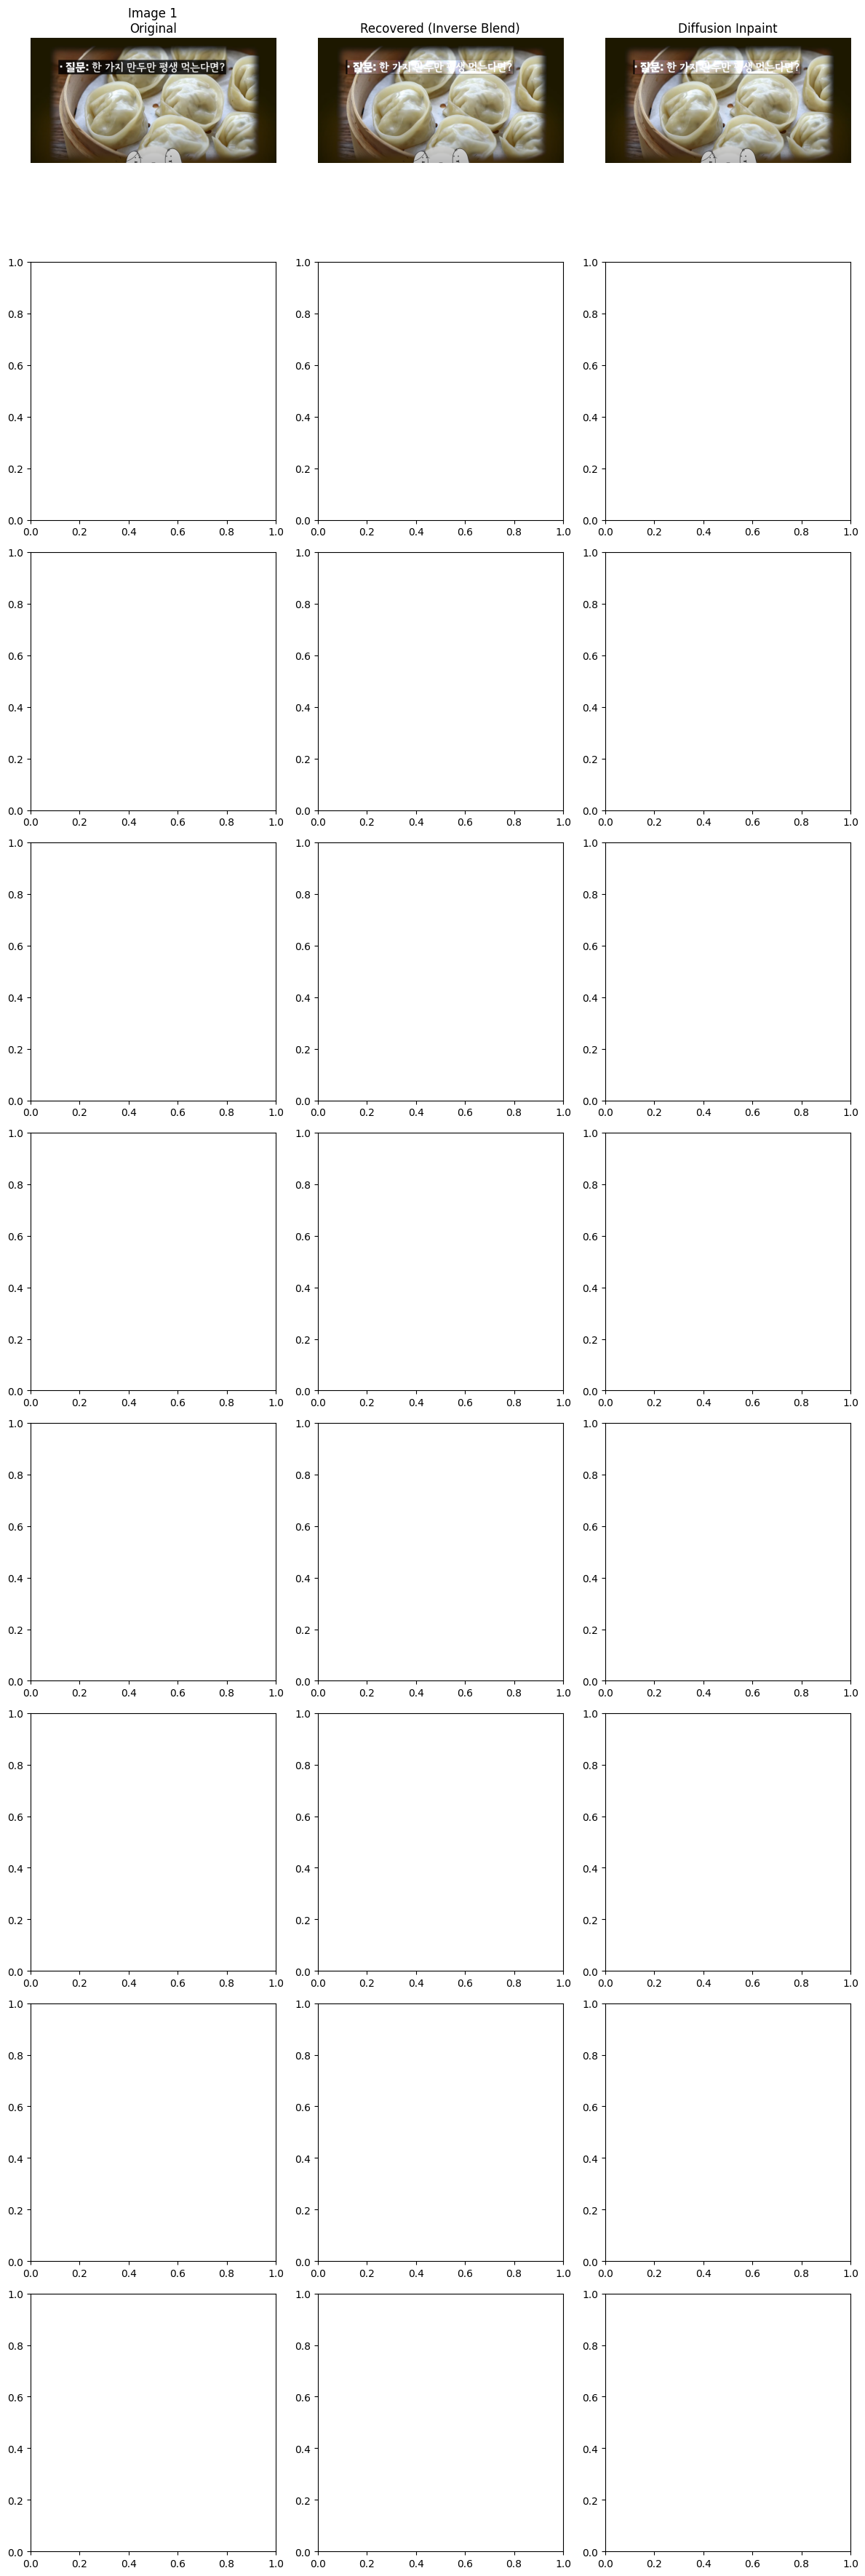

In [ ]:
# --------------------------------------------------------------------
# (2) 파이프라인: Original / Recovered / Diffusion Inpaint 결과 시각화
# --------------------------------------------------------------------

num_images = len(photo_list)  # 예: 9이라면 9

# 3열짜리 서브플롯 (Original | Recovered | Diffusion Inpaint)
fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))

for idx in range(1):
    # 1) 원본 이미지 로드 및 RGB 변환
    img_path = photo_list[idx]
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2) subtitle_mask, bbox 가져오기
    subtitle_mask = subtitle_mask_list[idx]  # Boolean mask (HxW)
    bbox = bbox_list[idx]                    # (x_min, y_min, x_max, y_max) 혹은 None

    # 3) bbox_mask 생성
    if bbox is not None:
        bbox_mask = make_bbox_mask(img_rgb, bbox)
    else:
        bbox_mask = np.zeros(img_rgb.shape[:2], dtype=bool)

    # 4) 역블렌드 (Cb, alpha 추정 → Recovered)
    Cb, alpha = estimate_box_color_and_opacity(
        img_rgb, bbox_mask, subtitle_mask,
        max_iter=100, tol=1e-6
    )
    recovered = apply_inverse_alpha_to_bbox(img_rgb, bbox_mask, Cb, alpha)

    # 5) diffusion inpaint 적용
    #   - recovered: [0,255] uint8 컬러 이미지
    #   - subtitle_mask: Boolean (HxW)
    #   5-1) recovered를 [0,1] float로 정규화
    rec_norm = recovered.astype(np.float32) / 255.0
    #   5-2) mask (True=자막 영역) 그대로 Boolean 사용
    #   5-3) 각 채널별로 diffusion inpaint 반복
    inpainted = np.zeros_like(rec_norm)
    num_iter = 333  # 반복 횟수: 많을수록 부드러움 ↑, 속도 ↓
    for c in range(3):
        inpainted[:, :, c] = fast_diffusion_inpaint(rec_norm[:, :, c], subtitle_mask, num_iter=num_iter)
    #   5-4) 다시 [0,255] uint8로 변환
    inpainted_uint8 = (inpainted * 255.0).round().astype(np.uint8)

    # 6) 시각화: Original, Recovered, Diffusion Inpaint
    ax0 = axes[idx, 0]
    ax1 = axes[idx, 1]
    ax2 = axes[idx, 2]

    ax0.imshow(img_rgb)
    ax0.set_title(f'Image {idx+1}\nOriginal')
    ax0.axis('off')

    ax1.imshow(recovered)
    ax1.set_title('Recovered (Inverse Blend)')
    ax1.axis('off')

    ax2.imshow(inpainted_uint8)
    ax2.set_title('Diffusion Inpaint')
    ax2.axis('off')

plt.tight_layout()
plt.show()
